<a href="https://colab.research.google.com/github/AquilaITOH/MedicalDataScience-exercises/blob/main/26Medical_datascience_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# メディカルデータサイエンス #5 パーセプトロンからディープラーニングへ

- パーセプトロン
  - 単純パーセプトロン(単相): 線形分類器
  - 多層パーセプトロン: 非線形分類器

- パーセプトロンを使った分類器
  - 単層パーセプトロンによる二次元での分類
  - ニューラルネットワーク(多層パーセプトロン)による二次元での分類
  - ハイパーパラメータの決定
  - ニューラルネットワークによる四次元での分類

## 各AIブームを牽引したAI技術

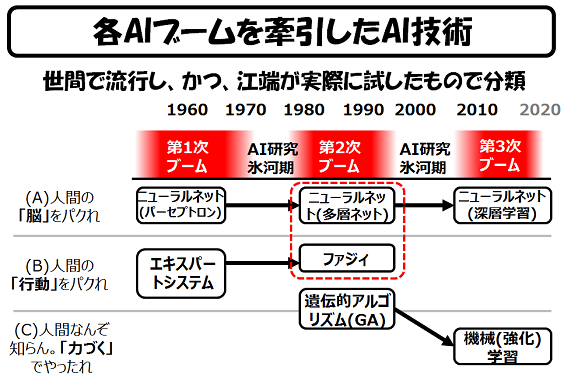

[江端智一. 不幸な人工知能 ～尊敬と軽蔑の狭間で揺れるニューラルネットワーク(2018)](https://eetimes.itmedia.co.jp/ee/articles/1804/27/news093.html)

## ニューロ・ファジィ家電の振り返り
[藤原義博, 若見昇, & 林勲. 松下電器から生まれたファジィ家電，ニューロ・ファジィ家電. 知能と情報 30, 14–23 (2018).](https://www.jstage.jst.go.jp/article/jsoft/30/1/30_14/_article/-char/ja/)

> 入力層のノードが3個、中間層が7個、出力層が1個の3層構造である(p.20)

#データ分析の準備
## ライブラリ・モジュールの読み込み

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets as datasets
import sklearn.decomposition as decomposition
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron # Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from matplotlib.colors import ListedColormap

## data setの読み込みとDFへのセット
Iris data setを読み込み、Pandas DataFrameにセットする

In [2]:
#import sklearn.datasets as datasets
iris_data = datasets.load_iris()

iris_df = pd.DataFrame(iris_data.data, columns = iris_data.feature_names)
iris_df["species"] = iris_data.target_names[iris_data.target]

# パーセプトロン
生物の神経細胞を模したもの。ニューラルネットワークの素子で、単純パーセプトロンは線型分類器である。

##パーセプトロン素子の動作

入力x1に重みw1をかける

入力x2に重みw2をかける

全部足して判定

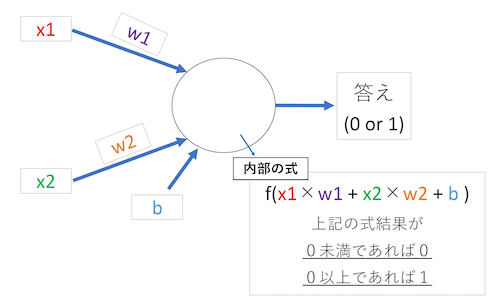

[機械学習・ディープラーニングについて「ど素人」が勉強してみました。 | 雑記ラボ](https://zakkilab.com/it/it-kikaigakusyu-sirouto/)


### 多クラス分類可能な単純パーセプトロン
[ 0, 1, 2] の三種類分類したい。(setosa, versicolor, virginica)

出力は3つ。どれかが1(0以上)になる。他は0

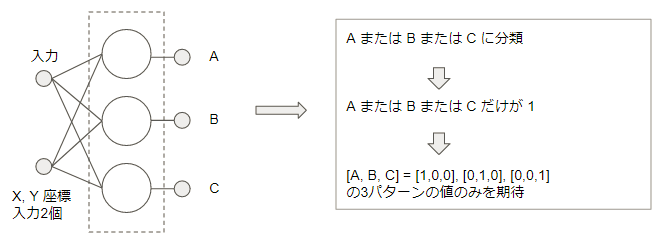

[入門 Keras (4) 多クラス分類 – Iris データを学習する｜技術ブログ｜北海道札幌市・宮城県仙台市のVR・ゲーム・システム開発 インフィニットループ](https://www.infiniteloop.co.jp/tech-blog/2018/01/learning-keras-04/)

#単層パーセプトロンでIrisを分類 (使用する特徴量は2次元)

scikt-learnのPerceptron を用いて多クラス分類をする。

[【初心者】ネコでも分かる「簡単な分類AI」の作り方【Python】](https://zenn.dev/nekoallergy/articles/sklearn-nn-iris)

## 分類に用いる特徴量の選択 (2次元のみ)
sepal length, sepal width, petal length, petal width

Pair plotを目視で確認し、三種類が分類できそうな特徴量を探す。

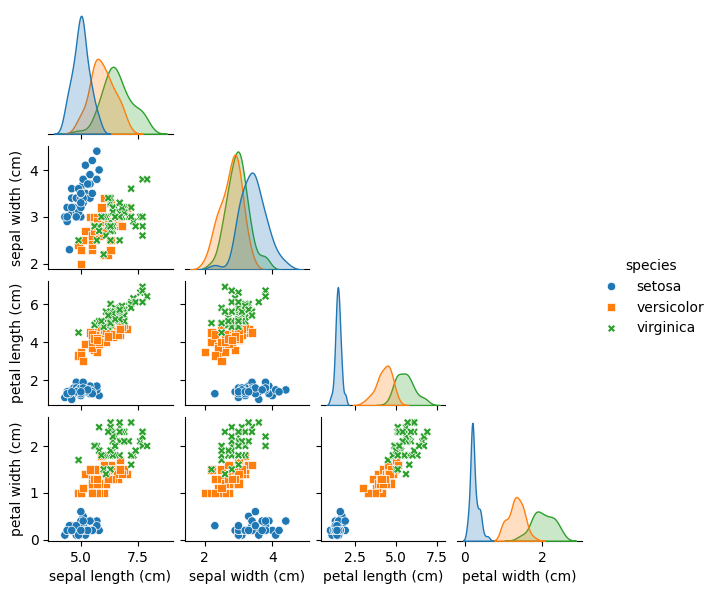

In [3]:
# ペアプロットの作成
sns.pairplot(iris_df, hue='species', markers=["o", "s", "X"],corner=True, height=1.5) #hueで品種ごとの色分け、corner=Trueで重複するplotを省略
plt.show()

In [4]:
# iris_dfの先頭3行を表示
iris_df.head(3)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


分類に用いる特徴量の選択

[0, 1, 2, 3] = [sepal length, sepal width, petal length, petal width]

たとえば…

- petal lengthとpetal width [2, 3] を特徴量として使う
- sepal widthとpetal Length[1,2]を特徴量に使う

class lebels = [setosa, versicolor, virginica]

In [6]:
feature_names = ['sepal length(cm)', 'sepal width(cm)', 'petal length(cm)', 'petal width(cm)']
selected_features = [2, 3]  # ここだけ変えれば全体に反映
X = iris_data.data[:, selected_features]
y = iris_data.target #正解ラベル

print('Class labels:', np.unique(y))

Class labels: [0 1 2]


## 前処理 データの分割

トレーニングデータとテストデータに分割する

X_train: トレーニング用データ 70%

X_test: テスト用データ 30%

y_tarain: トレーニング用正解ラベル 70%

y_test: テスト用正解ラベル 30%

random seed = 1234 (乱数を固定する)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1234, stratify=y)
print('Labels counts in y:', np.bincount(y))
print('Labels counts in y_train:', np.bincount(y_train))
print('Labels counts in y_test:', np.bincount(y_test))

Labels counts in y: [50 50 50]
Labels counts in y_train: [35 35 35]
Labels counts in y_test: [15 15 15]


選択した特徴量の分布

[[6.1 2.3]
 [1.4 0.1]
 [5.1 1.5]
 [5.4 2.1]
 [5.4 2.3]
 [3.8 1.1]
 [5.6 1.8]
 [3.9 1.2]
 [4.9 1.5]
 [1.5 0.4]
 [5.8 1.6]
 [1.2 0.2]
 [1.5 0.1]
 [4.6 1.5]
 [1.7 0.2]
 [5.3 2.3]
 [3.7 1. ]
 [5.  1.9]
 [3.5 1. ]
 [1.4 0.2]
 [1.6 0.2]
 [4.8 1.8]
 [1.5 0.2]
 [6.4 2. ]
 [4.4 1.4]
 [4.5 1.3]
 [1.3 0.2]
 [4.3 1.3]
 [1.6 0.2]
 [1.4 0.2]
 [4.5 1.5]
 [4.3 1.3]
 [5.5 1.8]
 [5.6 1.4]
 [4.  1.3]
 [3.9 1.4]
 [1.6 0.2]
 [1.4 0.2]
 [4.7 1.5]
 [4.2 1.5]
 [5.1 1.9]
 [1.  0.2]
 [1.5 0.2]
 [4.5 1.5]
 [1.9 0.4]
 [6.3 1.8]
 [4.2 1.3]
 [1.1 0.1]
 [1.5 0.4]
 [5.9 2.1]
 [5.  2. ]
 [5.1 2.4]
 [4.  1.2]
 [1.4 0.3]
 [1.5 0.2]
 [4.9 1.8]
 [5.6 2.4]
 [1.2 0.2]
 [1.5 0.2]
 [5.  1.7]
 [5.3 1.9]
 [4.4 1.2]
 [4.4 1.3]
 [5.2 2. ]
 [6.6 2.1]
 [6.  1.8]
 [4.5 1.7]
 [4.7 1.4]
 [6.9 2.3]
 [5.1 2. ]
 [4.2 1.3]
 [3.6 1.3]
 [6.7 2.2]
 [5.1 1.9]
 [3.3 1. ]
 [5.9 2.3]
 [5.5 1.8]
 [4.  1. ]
 [1.6 0.6]
 [5.1 1.6]
 [1.4 0.2]
 [1.4 0.2]
 [5.1 2.3]
 [4.1 1. ]
 [1.4 0.2]
 [5.6 2.1]
 [1.5 0.2]
 [1.3 0.2]
 [3.  1.1]
 [1.5 0.1]
 [4.7 1.4]

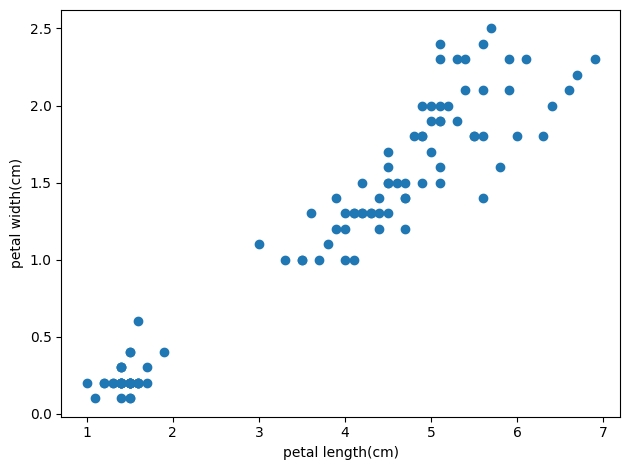

In [12]:
print(X_train)
print(y_train)
plt.scatter(X_train[:, 0], X_train[:, 1])
plt.xlabel(feature_names[selected_features[0]])
plt.ylabel(feature_names[selected_features[1]])
plt.tight_layout()
plt.show()

## 前処理 スケーリング
StandardScalerを使って、平均0, 分散1となるようにデータをスケーリングする。

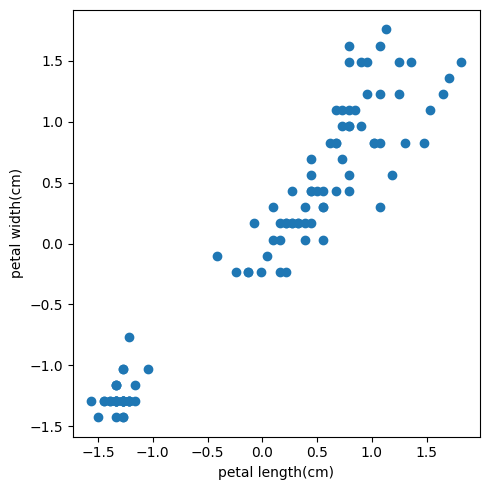

In [11]:
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

plt.figure(figsize=(5, 5))  # 正方形
plt.scatter(X_train_std[:,0],X_train_std[:,1])
plt.xlabel(feature_names[selected_features[0]])
plt.ylabel(feature_names[selected_features[1]])
plt.tight_layout()
plt.show()

スケーリング後のトレーニング用セットの特徴量

In [13]:
print(X_train_std)

[[ 1.35923928  1.49321026]
 [-1.33035408 -1.42746349]
 [ 0.78698537  0.43114708]
 [ 0.95866155  1.22769447]
 [ 0.95866155  1.49321026]
 [ 0.04305529 -0.09988451]
 [ 1.07311233  0.82942077]
 [ 0.10028068  0.03287338]
 [ 0.67253459  0.43114708]
 [-1.27312869 -1.0291898 ]
 [ 1.18756311  0.56390498]
 [-1.44480486 -1.2947056 ]
 [-1.27312869 -1.42746349]
 [ 0.50085842  0.43114708]
 [-1.15867791 -1.2947056 ]
 [ 0.90143615  1.49321026]
 [-0.0141701  -0.23264241]
 [ 0.72975998  0.96217867]
 [-0.12862088 -0.23264241]
 [-1.33035408 -1.2947056 ]
 [-1.2159033  -1.2947056 ]
 [ 0.6153092   0.82942077]
 [-1.27312869 -1.2947056 ]
 [ 1.53091545  1.09493657]
 [ 0.38640764  0.29838918]
 [ 0.44363303  0.16563128]
 [-1.38757947 -1.2947056 ]
 [ 0.32918225  0.16563128]
 [-1.2159033  -1.2947056 ]
 [-1.33035408 -1.2947056 ]
 [ 0.44363303  0.43114708]
 [ 0.32918225  0.16563128]
 [ 1.01588694  0.82942077]
 [ 1.07311233  0.29838918]
 [ 0.15750608  0.16563128]
 [ 0.10028068  0.29838918]
 [-1.2159033  -1.2947056 ]
 

## 単層パーセプトロンを作成

分類のために単層パーセプトロンを作成する

In [14]:
#from sklearn.linear_model import Perceptron
#エポック数100、学習率0.1でパーセプトロンのインスタンスを作成(rand generatorのseed:random_state=1234)
ppn = Perceptron(max_iter=100, tol=1e-3, eta0=0.1, random_state=1234)


### 学習 トレーニングデータによる予測モデル学習

トレーニングデータを使ってパーセプトロンを学習する

In [15]:
#トレーニングデータをモデルに適合させる
ppn.fit(X_train_std, y_train)

Perceptron(eta0=0.1, max_iter=100, random_state=1234)

### 評価 テストデータによる精度評価
テストデータにおける精度（的中率）を計算する。

In [16]:
#テストデータの分類、結果の取得
y_pred = ppn.predict(X_test_std)
print('誤分類: %d' % (y_test != y_pred).sum())
print('テスト正答率: %.2f' % accuracy_score(y_test, y_pred))

誤分類: 7
テスト正答率: 0.84


## 単層パーセプトロンモデルの重み(w)と切片(Bias)

- x1, x2... : 特徴量
- w11, w12... : 重み
- x1w11 + x2w12 全部たす
- Bias: b1 それに一定の数たす

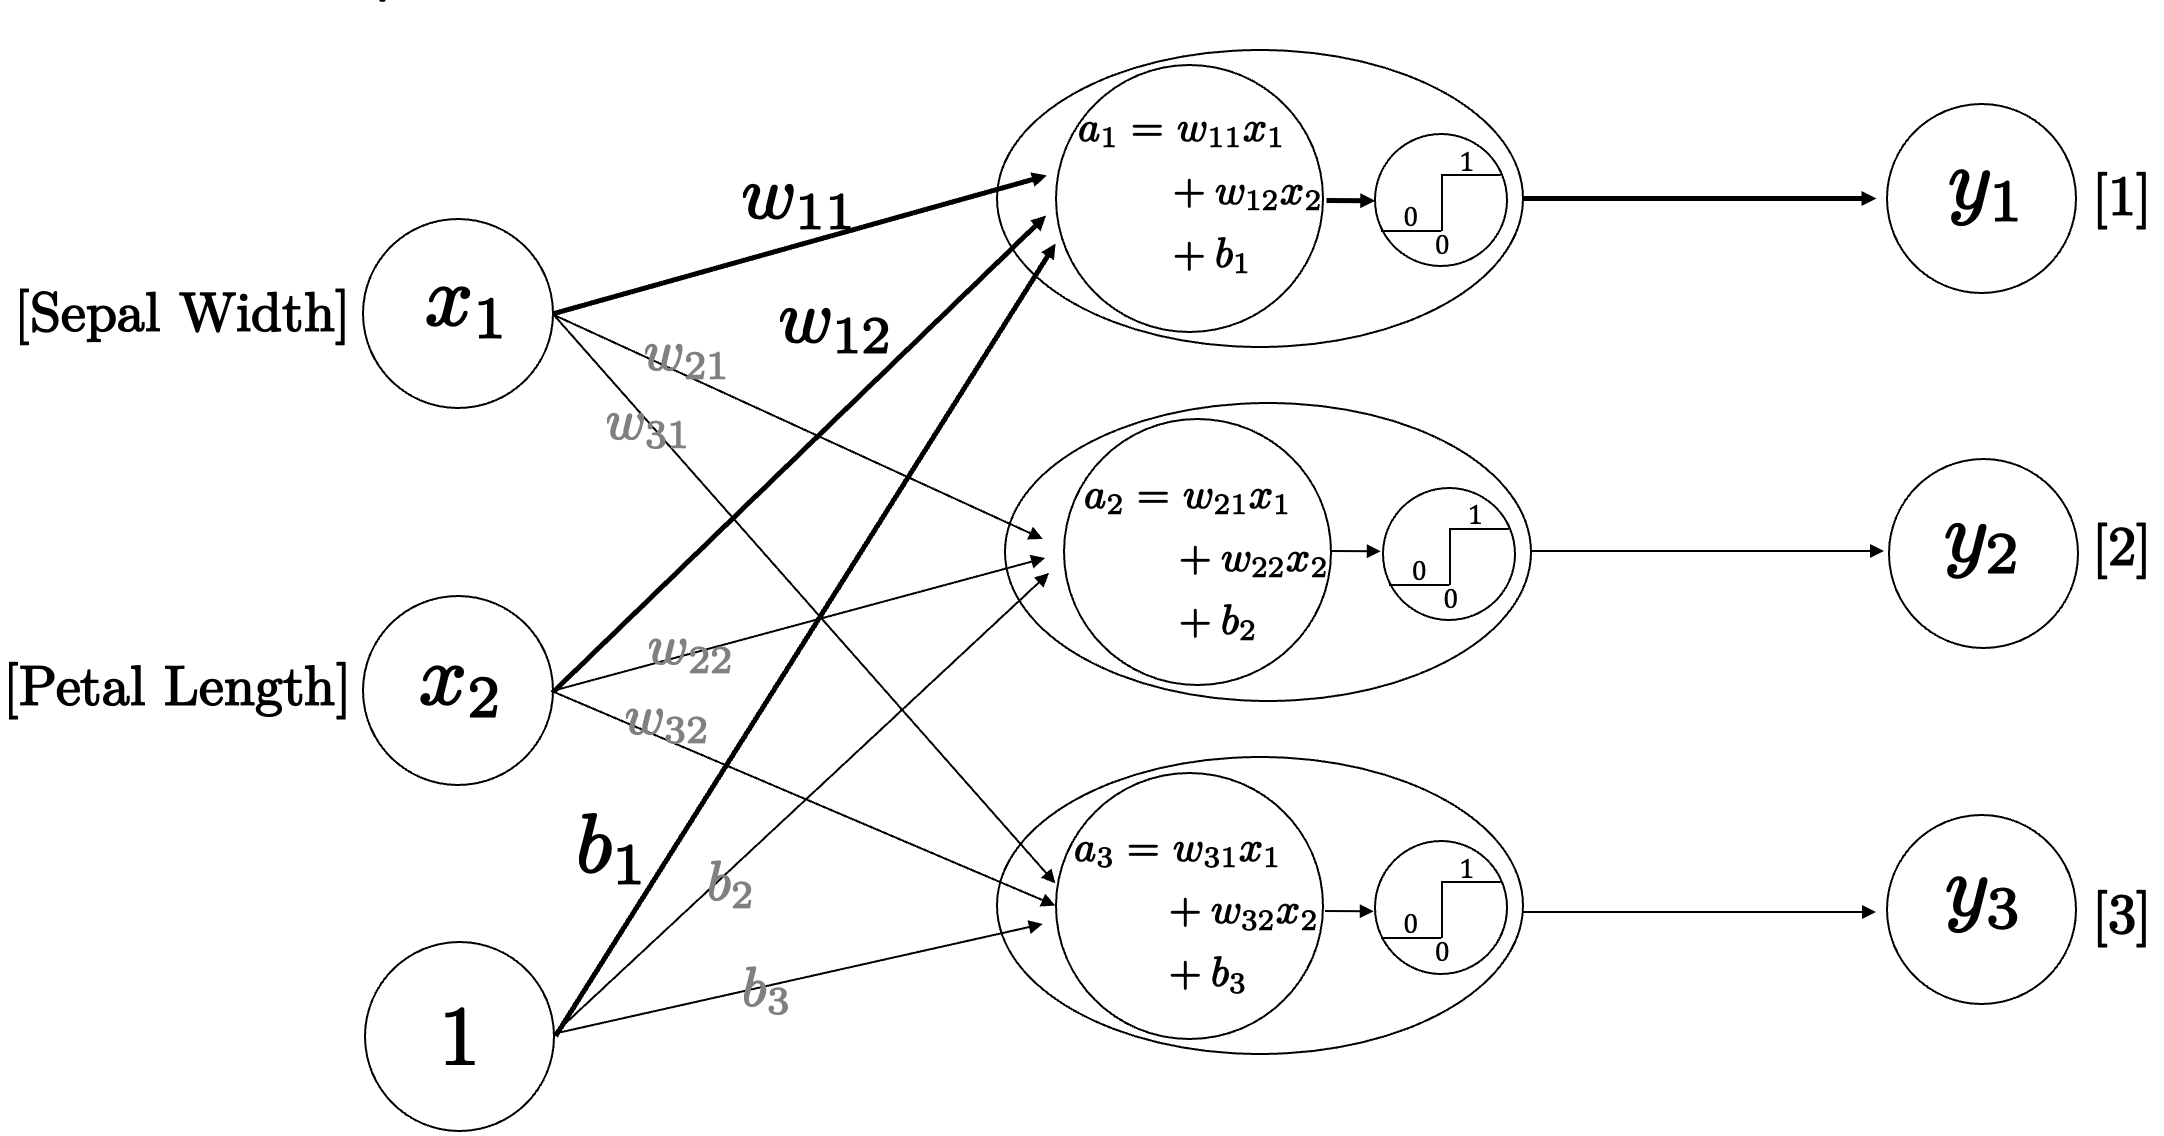


### トレーニングデータを用いて得られた重み(w)と切片(Bias)

- クラスラベル: 結果の分類
- 重み: 3行2列の行列
- 切片: 1行3列の行列


In [17]:
cls = ppn.classes_
coef= ppn.coef_
intrcpt = ppn.intercept_
print("分類クラスのユニークなクラスラベル =",ppn.classes_)
print("特徴量に割り当てられた重み",ppn.coef_)
print("切片",ppn.intercept_)

分類クラスのユニークなクラスラベル = [0 1 2]
特徴量に割り当てられた重み [[-0.13592393 -0.09621787]
 [ 0.40630027 -0.11948211]
 [ 0.26890484  0.37184855]]
切片 [-1.00000000e-01 -2.77555756e-17 -4.00000000e-01]


### 行列演算による推論

行列を使ってパーセプトロンの出力を計算してみる

重みと切片を使ってパーセプトロンの出力(y1, y2, y3)を計算してみよう。

特徴量に重みをかけて総和をとり、切片をたす。行列を使うと式をコンパクトに表現できる。

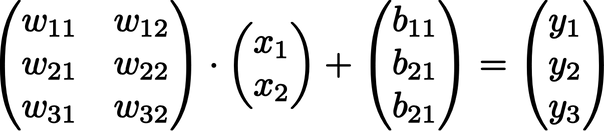

In [18]:
n_raw = 0
a_in = X_test_std[n_raw,:]#特徴量
print("input: %s" %a_in)
print("y_test: %i" %(y_test[n_raw]))
print("y_pred: %i" %(y_pred[n_raw]))
#a_in = np.array([in1 , in2]) #入力
t_coef = np.transpose(coef) #特徴量
out = np.dot(a_in,t_coef) + intrcpt
print("output: %s" %out)
print("output(bool): %s" %(out>0)) #活性化関数はステップ関数
print("max value index: %s" %(np.argmax(out)))

input: [0.84421076 1.49321026]
y_test: 2
y_pred: 2
output: [-0.35842195  0.16459115  0.38226043]
output(bool): [False  True  True]
max value index: 2


### 正解を確認
test_dataの[n_raw]項目

In [22]:
print(X_test_std[n_raw,:]) #特徴量
print(y_test[n_raw]) #正解ラベル

[0.84421076 1.49321026]
2


**正解！**

### テストデータセット全部を行列演算で推論してみる

In [19]:
i = 0 # インデックス値の初期値 0 を設定
len_in = len(X_test_std)
t_coef = np.transpose(coef) #転置

# インデックス値 < len_in の間、ループを繰り返す
while i < len_in:
  a_in = X_test_std[i,:]#特徴量
  print("input: %s" %a_in)
  print("y_test: %i" %(y_test[i]))
  print("y_pred: %i" %(y_pred[i]))
  out = np.dot(a_in,t_coef) + intrcpt
  print("output: %s" %out)
  print("output(bool): %s" %(out>0)) #活性化関数はステップ関数
  print("max value index: %s" %(np.argmax(out)))
  print("---")
  i+=1

input: [0.84421076 1.49321026]
y_test: 2
y_pred: 2
output: [-0.35842195  0.16459115  0.38226043]
output(bool): [False  True  True]
max value index: 2
---
input: [1.01588694 1.22769447]
y_test: 2
y_pred: 2
output: [-0.35620949  0.26606762  0.32969332]
output(bool): [False  True  True]
max value index: 2
---
input: [1.07311233 1.62596816]
y_test: 2
y_pred: 2
output: [-0.40230883  0.24173173  0.493179  ]
output(bool): [False  True  True]
max value index: 2
---
input: [-1.38757947 -1.2947056 ]
y_test: 0
y_pred: 0
output: [ 0.21317906 -0.40907977 -1.25456123]
output(bool): [ True False False]
max value index: 0
---
input: [1.30201389 1.75872606]
y_test: 2
y_pred: 2
output: [-0.44619571  0.3188723   0.60409757]
output(bool): [False  True  True]
max value index: 2
---
input: [-1.2159033 -1.2947056]
y_test: 0
y_pred: 0
output: [ 0.18984416 -0.33932769 -1.20839668]
output(bool): [ True False False]
max value index: 0
---
input: [-1.38757947 -1.2947056 ]
y_test: 0
y_pred: 0
output: [ 0.21317906 

## 評価 予測モデルの可視化
予測モデルの線形関数を散布図にプロットする。

In [23]:
#from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=cl,
                    edgecolor='black')

    # highlight test samples
    if test_idx:
        # plot all samples
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
            X_test[:, 1],
            facecolor='none',
            edgecolor='black',
            alpha=1.0,
            linewidth=1,
            marker='o',
            s=100,
            label='test set')

Plot

/tmp/ipykernel_843/1832641858.py:22: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


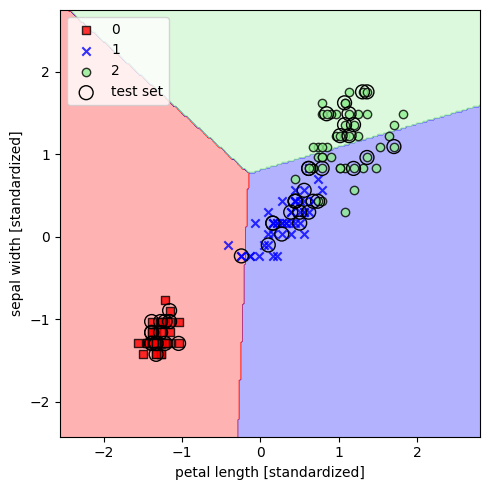

In [25]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))
plt.figure(figsize=(5, 5))  # 正方形
plot_decision_regions(X=X_combined_std, y=y_combined,
                      classifier=ppn, test_idx=range(105, 150))
plt.xlabel('petal length [standardized]')
plt.ylabel('sepal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

#トレーニング(学習）とは？

機械学習モデルのパラメーターを自動的に調整していくこと。
- 重み(w)
- 切片(bias)

## [w]や[B]の中身を自動的に計算したい

モデルを算出するということは、[w]や[B]の要素を知ること。次元が少なければ解析解を得ることも可能。次元が多くなると困難になる。

そこでデータを用いて探索的に解を求める。これが**データ駆動**。

### 単層パーセプトロンのトレーニング

単層パーセプトロンは比較的簡単。

1. [w] ((w11, w12),(w21,w22),(w31,w32)) にとりあえずランダムな値を設定する
2. トレーニングデータ(x1, x2)を一つ読み込み計算をして (y1, y2, y3)を正解と照合する。
3.  (y1, y2, y3)が正解と違っていれば、[w]の値を「正しそうな方向」に少しずらす
4. 2-3を繰り返し、全てのトレーニングデータについて正しい出力が得られたら終了

これを重みベクトルの自動更新と呼ぶ

「正しそうな方向」がwを増やす方向か、減らす方かは、**損失関数**の傾きで判断する。

## 勾配降下法

「ある教師データを読み込ませたときの出力がどれくらい期待外れだったか？」を数値で返す関数 E があるとする。

これを誤差関数、あるいは**損失関数**と呼ぶ。

この関数は「出力が期待外れであるほど大きな値を返す」ものであれば何でも良い

誤差関数の出力値は「期待外れの度合い」なので、それを最小にできれば学習完了したと見なせる。

[w]をランダムな値で初期化してから少しずつ動かしていき、誤差関数の出力値を最小にする。

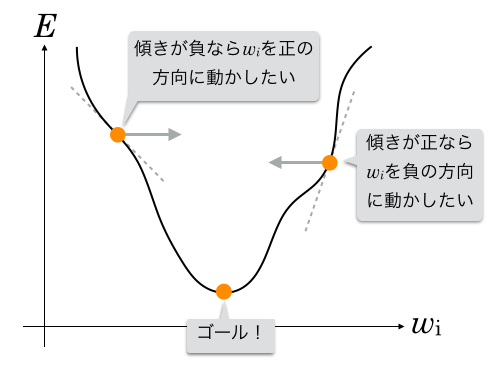

このグラフで「誤差Eが一番小さくなるw_i」は曲線が下方向に突起している箇所なので、目指したいのはここ。

- 現在のw_iでグラフの傾きが正の場合 → w_i を負の方向に動かす
- 現在のw_iでグラフの傾きが負の場合 → w_i を正の方向に動かす

[http://hokuts.com/2015/11/25/ml2_perceptron/](http://hokuts.com/2015/11/25/ml2_perceptron/)

#多層パーセプトロン(ニューラルネットワーク)でIrisを分類

[【初心者】ネコでも分かる「簡単な分類AI」の作り方【Python】](https://zenn.dev/nekoallergy/articles/sklearn-nn-iris)

## 分類に用いる特徴の選択
分類に用いる特徴量の選択

[0, 1, 2, 3] = [sepal length, sepal width, petal length, petal width]

In [26]:
X = iris_data.data[:, selected_features]
feature_names = ['sepal length(cm)', 'sepal width(cm)', 'petal length(cm)', 'petal width(cm)']
selected_features = [2, 3]  # ここだけ変えれば全体に反映
X = iris_data.data[:, selected_features]
y = iris_data.target #正解ラベル

print('Class labels:', np.unique(y))

Class labels: [0 1 2]


## 前処理 データの分割

トレーニングデータとテストデータに分割する

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1234, stratify=y)

## 前処理 スケーリング
StandardScalerを使って、平均0, 分散1となるようにデータをスケーリングする。

In [28]:
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

## ニューラルネットワークの作成

2層目の隠れ層は5個の、3層型ニューラルネットワーク

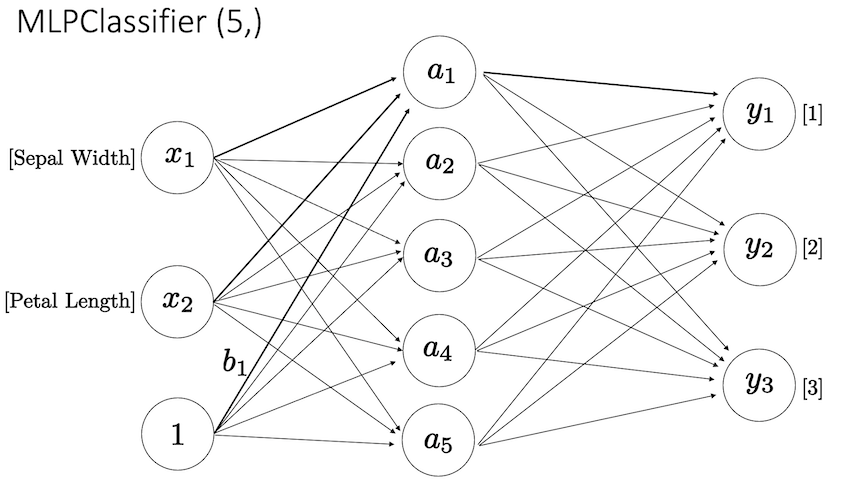

In [29]:
# Scikit Learnのニューラルネットワークのライブラリを読み込む
# from sklearn.neural_network import MLPClassifier
# ニューラルネットワークのモデルを作成
clf5 = MLPClassifier(hidden_layer_sizes=(5,), activation='relu',
                    solver='adam', max_iter=1000)
#hidden_layer_sizes 中間層(隠れ層)のサイズ (5,)2層目の隠れ層は5個の、3層型NN
#activation 活性化関数
#solver 最適化手法
#max_iter 繰り返し回数

## 学習 トレーニングデータによる予測モデル学習

In [30]:
# Lerning model
clf5.fit(X_train_std, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000)

## 評価 トレーニングデータによる精度評価

In [32]:
# Calculate prediction accuracy
print("トレーニング正答率: %.2f" %clf5.score(X_train_std, y_train))

トレーニング正答率: 0.96


## 評価 テストデータによる精度評価

交差検定: cross validation

In [33]:
# Predict test data
print("予測: %s" %clf5.predict(X_test_std))
print("教師: %s" %y_test)

# score
y_pred = clf5.predict(X_test_std)
print('誤分類: %d' % (y_test != y_pred).sum())
print('テスト正答率: %.2f' % accuracy_score(y_test, y_pred))

予測: [2 2 2 0 2 0 0 2 1 0 1 0 1 2 0 0 1 2 1 0 0 2 0 1 2 0 1 2 1 1 2 1 1 1 2 0 2
 2 1 1 2 0 1 0 0]
教師: [2 2 2 0 2 0 0 1 1 0 1 0 1 2 0 0 1 2 1 0 0 2 0 1 2 0 1 2 1 1 2 2 1 1 2 0 2
 2 1 1 2 0 1 0 0]
誤分類: 2
テスト正答率: 0.96


それぞれの予測に対するモデルの確信度を確認する。

In [34]:
# confidence level
pd.DataFrame(clf5.predict_proba(X_test_std))

,0,1,2
0,1.942935e-06,0.026356,0.973642
1,7.878234e-06,0.063057,0.936935
2,3.913030e-07,0.014203,0.985796
3,7.136286e-01,0.143844,0.142527
4,7.835651e-08,0.007610,0.992390
5,7.136286e-01,0.143844,0.142527
6,7.136286e-01,0.143844,0.142527
7,3.426560e-04,0.275591,0.724066
8,4.773255e-03,0.651443,0.343784
9,6.341987e-01,0.219546,0.146255


## 学習過程の表示

学習を繰り返すほど損失関数が減少する。

減少の程度を確認し、必要な学習回数(Iteration)を決める。

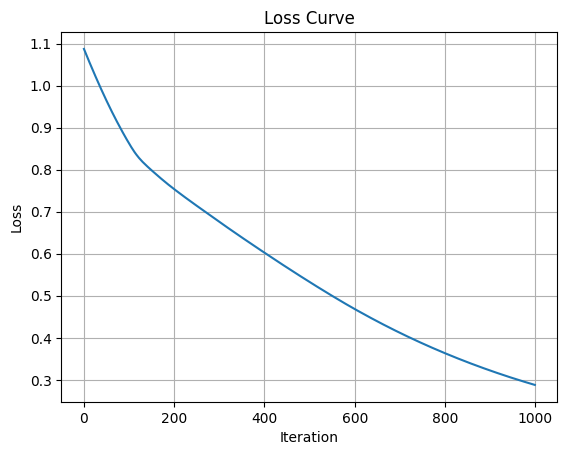

In [35]:
# Show loss function (数列表示)
# print(clf5.loss_curve_)

# Show loss curve
plt.plot(clf5.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()

## 特徴空間の可視化


/tmp/ipykernel_843/4035606091.py:15: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x1tr, y1tr, alpha=0.8, marker="x", c='blue',edgecolor='black',label="Versicolor")
/tmp/ipykernel_843/4035606091.py:27: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x1ts, y1ts, alpha=0.8, marker="x", c='blue',edgecolor='black')


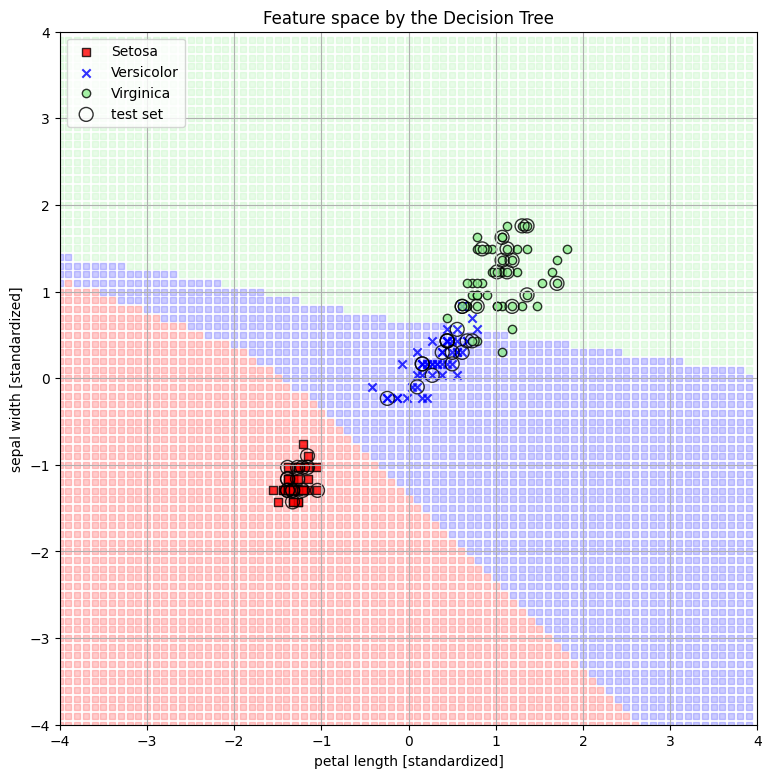

In [37]:
# 推論(Setosa, Versicolor, Virginica領域)
plt.figure(figsize=(9,9))
plt.scatter(x_mesh[z==0], y_mesh[z==0], s=20, alpha=0.2, marker="s", c='red')
plt.scatter(x_mesh[z==1], y_mesh[z==1], s=20, alpha=0.2, marker="s", c='blue')
plt.scatter(x_mesh[z==2], y_mesh[z==2], s=20, alpha=0.2, marker="s", c='lightgreen')

#トレーニングデータ(Setosa, Versicolor, Virginica)
x0tr = X_train_std[y_train==0][:, 0] #ブール配列によるマスキング
y0tr = X_train_std[y_train==0][:, 1]
x1tr = X_train_std[y_train==1][:, 0]
y1tr = X_train_std[y_train==1][:, 1]
x2tr = X_train_std[y_train==2][:, 0]
y2tr = X_train_std[y_train==2][:, 1]
plt.scatter(x0tr, y0tr, alpha=0.8, marker="s", c='red', edgecolor='black',label="Setosa")
plt.scatter(x1tr, y1tr, alpha=0.8, marker="x", c='blue',edgecolor='black',label="Versicolor")
plt.scatter(x2tr, y2tr, alpha=0.8, marker="o", c='lightgreen',edgecolor='black',label="Virginica")

#テストデータ(Setosa, Versicolor, Virginica)
x0ts = X_test_std[y_test==0][:, 0]
y0ts = X_test_std[y_test==0][:, 1]
x1ts = X_test_std[y_test==1][:, 0]
y1ts = X_test_std[y_test==1][:, 1]
x2ts = X_test_std[y_test==2][:, 0]
y2ts = X_test_std[y_test==2][:, 1]
plt.scatter(x0ts, y0ts, alpha=0.8, marker="s", c='red', edgecolor='black')
plt.scatter(x0ts, y0ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black',label='test set')
plt.scatter(x1ts, y1ts, alpha=0.8, marker="x", c='blue',edgecolor='black')
plt.scatter(x1ts, y1ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black')
plt.scatter(x2ts, y2ts, alpha=0.8, marker="o", c='lightgreen',edgecolor='black')
plt.scatter(x2ts, y2ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black')


plt.title("Feature space")
plt.xlabel('petal length [standardized]')
plt.ylabel('sepal width [standardized]')
plt.grid(True)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.legend(loc='upper left')
#plt.legend(["Setosa", "Versicolor", "Virginica"], loc="upper right", bbox_to_anchor=(1.3, 1))

### 適切なハイパーパラメータの探索

モデルに手動で与えなければならないパラメータをハイパーパラメータと呼ぶ(ニューラルネットワークの隠れ層の数など)。これを片っ端から試して適当な組み合わせを探索する方法として、**グリッドサーチ**がある。
考えられる組み合わせを全て計算してみる方法である。

In [46]:
# Grid Search with 交差検証（特徴量2つ）
results = []
for hidden_layer_sizes in [5, 10, 100, 1000]:
    for solver in ['sgd', 'adam', 'lbfgs']:
        for activation in ['identity', 'logistic', 'tanh', 'relu']:
            for learning_rate_init in [0.1, 0.01, 0.001]:
                clf = MLPClassifier(max_iter=10000,
                       hidden_layer_sizes=(hidden_layer_sizes,),
                       activation=activation, solver=solver,
                       learning_rate_init=learning_rate_init)
                scores = cross_val_score(clf, X_train_std, y_train, cv=5)
                results.append([hidden_layer_sizes, activation,
                       solver, learning_rate_init,
                       scores.mean(), scores.std()])

# 結果表示
df_results = pd.DataFrame(
    sorted(results, key=lambda f: f[4], reverse=True),
    columns=["hidden_layer_sizes", "activation", "solver",
             "learning_rate_init", "score_mean", "score_std"]
)
df_results

,hidden_layer_sizes,activation,solver,learning_rate_init,score_mean,score_std
0,5,relu,sgd,0.001,0.980952,0.023328
1,5,logistic,lbfgs,0.100,0.980952,0.023328
2,5,tanh,lbfgs,0.010,0.971429,0.038095
3,100,tanh,lbfgs,0.010,0.971429,0.038095
4,5,tanh,sgd,0.001,0.971429,0.023328
...,...,...,...,...,...,...
139,1000,tanh,adam,0.100,0.933333,0.048562
140,5,logistic,sgd,0.001,0.914286,0.019048
141,1000,identity,adam,0.100,0.895238,0.076190
142,1000,logistic,adam,0.100,0.657143,0.224164


最良の結果となった組み合わせで新しくニューラルネットワーク(clf6)を作成する。



In [47]:
# ニューラルネットワークのモデルを作成
clf6 = MLPClassifier(hidden_layer_sizes=(5,), activation='relu',
                    solver='sgd', learning_rate_init = 0.001, max_iter=1000)
#hidden_layer_sizes 中間層(隠れ層)のサイズ (5,)2層目の隠れ層は5個の、3層型NN
#activation 活性化関数
#solver 最適化手法
#max_iter 繰り返し回数

# Lerning model
clf6.fit(X_train_std, y_train)

# Calculate prediction accuracy
print("トレーニング正答率: %.2f" %clf6.score(X_train_std, y_train))

# Predict test data
print("予測: %s" %clf6.predict(X_test_std))
print("教師: %s" %y_test)

# score
y_pred = clf6.predict(X_test_std)
print('誤分類: %d' % (y_test != y_pred).sum())
print('テスト正答率: %.2f' % accuracy_score(y_test, y_pred))

# confidence level
conf_clf6 = pd.DataFrame(clf6.predict_proba(X_test_std))
conf_clf6.head(10)

# Show loss function
#print(clf6.loss_curve_)

トレーニング正答率: 0.96
予測: [2 2 2 0 2 0 0 2 1 0 1 0 1 2 0 0 1 2 1 0 0 2 0 2 2 0 1 2 2 2 2 2 1 1 2 0 2
 2 1 1 2 0 1 0 0]
教師: [2 2 2 0 2 0 0 1 1 0 1 0 1 2 0 0 1 2 1 0 0 2 0 1 2 0 1 2 1 1 2 2 1 1 2 0 2
 2 1 1 2 0 1 0 0]
誤分類: 4
テスト正答率: 0.91


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,0,1,2
0,0.001975,0.165198,0.832826
1,0.002288,0.144935,0.852777
2,0.000688,0.096211,0.903101
3,0.614122,0.312032,0.073846
4,0.000231,0.054108,0.945661
5,0.614122,0.312032,0.073846
6,0.614122,0.312032,0.073846
7,0.018930,0.360598,0.620472
8,0.067467,0.507771,0.424762
9,0.571456,0.347686,0.080858


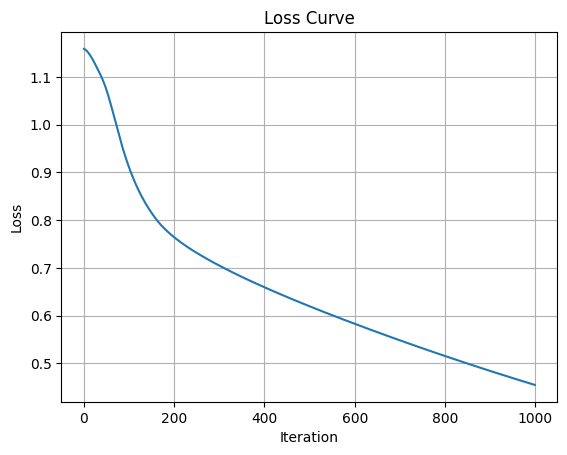

In [48]:
# Show loss curve
plt.plot(clf6.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()

### 標本空間の可視化

/tmp/ipykernel_843/3425893539.py:15: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x1tr, y1tr, alpha=0.8, marker="x", c='blue',edgecolor='black',label="Versicolor")
/tmp/ipykernel_843/3425893539.py:27: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x1ts, y1ts, alpha=0.8, marker="x", c='blue',edgecolor='black')


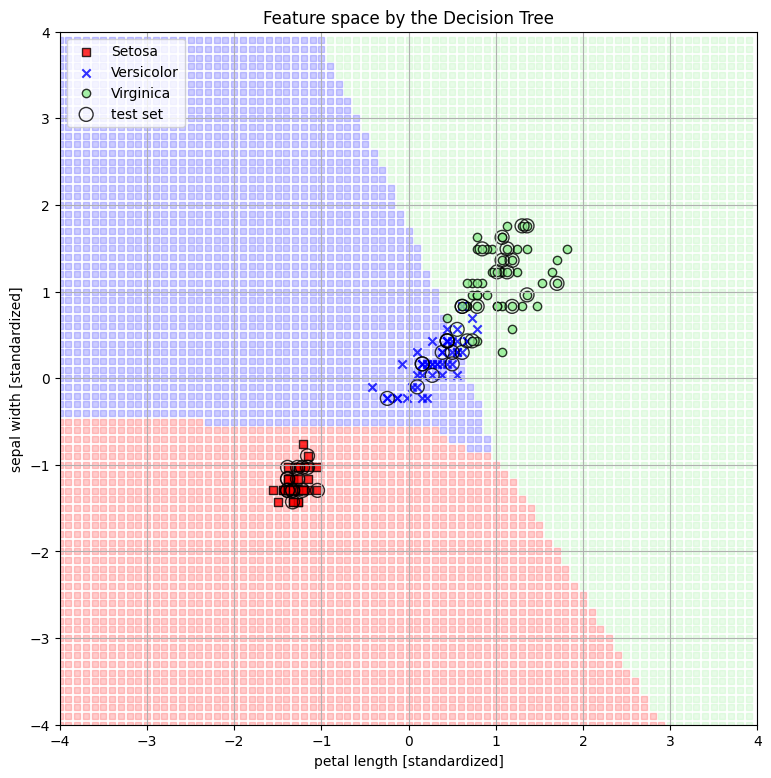

In [75]:
# PyLearnMLCR01: 決定木 | 知能情報システム工学研究室 – 日本大学生産工学部マネジメント工学科
# http://int-info.com/PyLearn/PyLearnMLCR01.html
# 推論(Setosa, Versicolor, Virginica領域)
plt.figure(figsize=(9,9))
plt.scatter(x_mesh[z6==0], y_mesh[z6==0], s=20, alpha=0.2, marker="s", c='red')
plt.scatter(x_mesh[z6==1], y_mesh[z6==1], s=20, alpha=0.2, marker="s", c='blue')
plt.scatter(x_mesh[z6==2], y_mesh[z6==2], s=20, alpha=0.2, marker="s", c='lightgreen')

#トレーニングデータ(Setosa, Versicolor, Virginica)
x0tr = X_train_std[y_train==0][:, 0] #ブール配列によるマスキング
y0tr = X_train_std[y_train==0][:, 1]
x1tr = X_train_std[y_train==1][:, 0]
y1tr = X_train_std[y_train==1][:, 1]
x2tr = X_train_std[y_train==2][:, 0]
y2tr = X_train_std[y_train==2][:, 1]
plt.scatter(x0tr, y0tr, alpha=0.8, marker="s", c='red', edgecolor='black',label="Setosa")
plt.scatter(x1tr, y1tr, alpha=0.8, marker="x", c='blue',edgecolor='black',label="Versicolor")
plt.scatter(x2tr, y2tr, alpha=0.8, marker="o", c='lightgreen',edgecolor='black',label="Virginica")

#テストデータ(Setosa, Versicolor, Virginica)
x0ts = X_test_std[y_test==0][:, 0]
y0ts = X_test_std[y_test==0][:, 1]
x1ts = X_test_std[y_test==1][:, 0]
y1ts = X_test_std[y_test==1][:, 1]
x2ts = X_test_std[y_test==2][:, 0]
y2ts = X_test_std[y_test==2][:, 1]
plt.scatter(x0ts, y0ts, alpha=0.8, marker="s", c='red', edgecolor='black')
plt.scatter(x0ts, y0ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black',label='test set')
plt.scatter(x1ts, y1ts, alpha=0.8, marker="x", c='blue',edgecolor='black')
plt.scatter(x1ts, y1ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black')
plt.scatter(x2ts, y2ts, alpha=0.8, marker="o", c='lightgreen',edgecolor='black')
plt.scatter(x2ts, y2ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black')


plt.title("Feature space")
plt.xlabel('petal length [standardized]')
plt.ylabel('sepal width [standardized]')
plt.grid(True)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.legend(loc='upper left')
#plt.legend(["Setosa", "Versicolor", "Virginica"], loc="upper right", bbox_to_anchor=(1.3, 1))

# 分類に **4次元** すべての特徴量を使う
## 4次元の特徴量で分類する
下記4次元の特徴量で分類する。2次元より高い精度で分類できるはず。
- Sepal.Length (がく)
- Sepal.Width
- Petal.Length (花弁)
- Petal.Width

## 前処理 データの分割

In [51]:
# Split the dataset
data_train, data_test, target_train, target_test = train_test_split(
    iris_data.data, iris_data.target, test_size=0.3, random_state=0)

## 前処理 データのスケーリング

In [52]:
sc = StandardScaler()
sc.fit(data_train)
data_train_std = sc.transform(data_train)
data_test_std = sc.transform(data_test)

## ニューラルネットワークの作成

4入力2層目の隠れ層は10個の、3層型ニューラルネットワーク
(下図は隠れ層5個で描画)
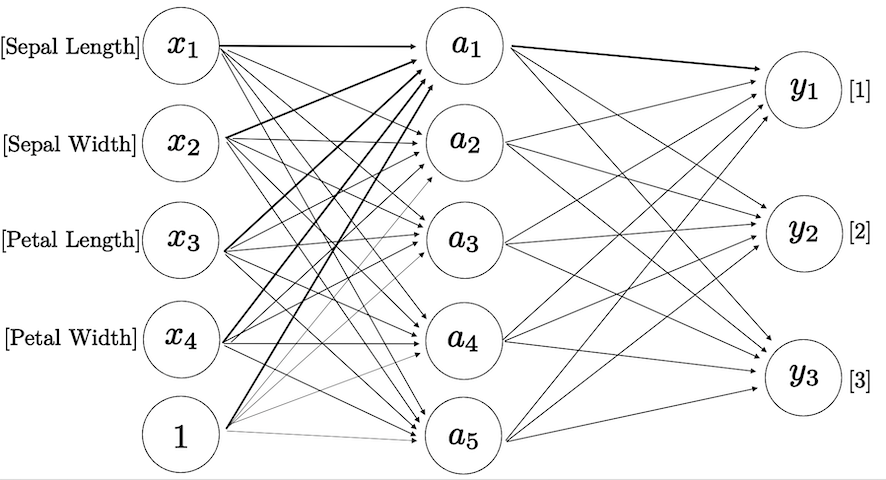



In [53]:
# Scikit Learnのニューラルネットワークのライブラリを読み込む
# from sklearn.neural_network import MLPClassifier
# ニューラルネットワークのモデルを作成
clf4 = MLPClassifier(hidden_layer_sizes=(10,), activation='relu',
                    solver='adam', max_iter=500)
#hidden_layer_sizes 中間層(隠れ層)のサイズ (10,)2層目の隠れ層は10個の、3層型NN
#activation 活性化関数
#solver 最適化手法
#max_iter 繰り返し回数


## 学習 トレーニングデータによる予測モデル学習

In [54]:
# Lerning model
clf4.fit(data_train_std, target_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(10,), max_iter=500)

## 評価 トレーニングデータによる精度評価

In [56]:
# Calculate prediction accuracy
print("トレーニング正答率: %.2f" %clf4.score(data_train_std, target_train))

トレーニング正答率: 0.94


## 評価 テストデータによる精度評価

In [57]:
# Predict test data
print("予測: %s" %clf4.predict(data_test_std))
print("教師: %s" %target_test)

target_pred = clf4.predict(data_test_std)
print('誤分類: %d' % (target_test != target_pred).sum())
print('テスト正答率: %.2f' % accuracy_score(target_test, target_pred))

予測: [2 1 0 2 0 2 0 2 1 1 2 2 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2 1 1 2 0 2 0 0]
教師: [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1 1 1 2 0 2 0 0]
誤分類: 3
テスト正答率: 0.93


## 学習過程の表示

損失関数の減少過程を確認する。

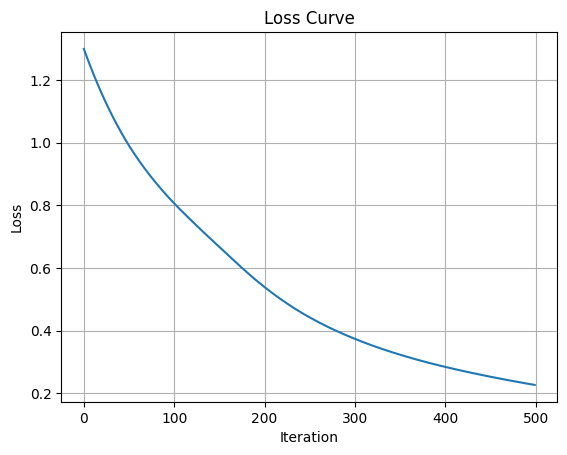

In [59]:
# Show loss curve
plt.plot(clf4.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()

## 特徴空間の可視化は可能か？

特徴量を4つ使って分類しているため、特徴空間は4次元になる。視覚化は困難。

# 多層パーセプトロン

隠れ層を増やす
- a(1)
- a(2)

隠れ層が3層以上あるもの→ **ディープニューラルネットワーク**



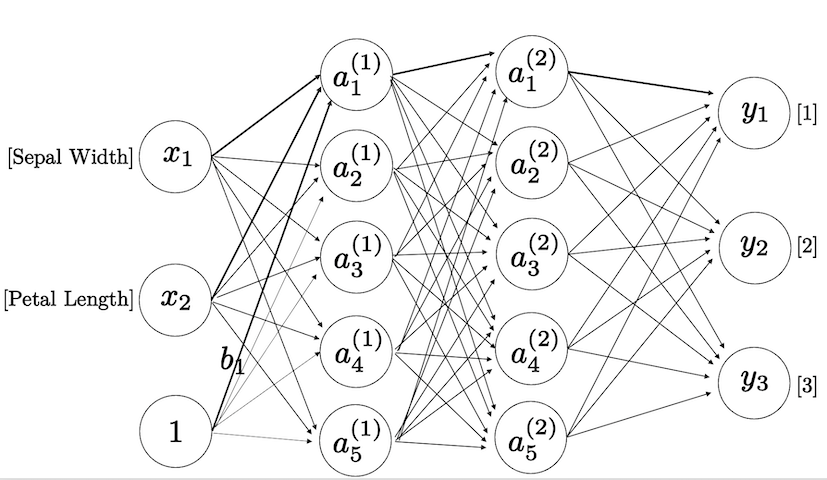

## 多層ニューラルネットワークの学習

乱数シードと勾配降下法だけでは多層NNの学習は不可能。

一層目の重みを調整しても、二層目以降の重みで損失はいかようにも変わる。


### 誤差逆伝播法

教師データを入力し、出力の正解との照らし合わせで答え合わせをしながら、重み付けの調整を推論と逆方向に行い、精度を上げていく学習方法。

誤差逆伝播法が確立して、多層NNの学習が可能になった。

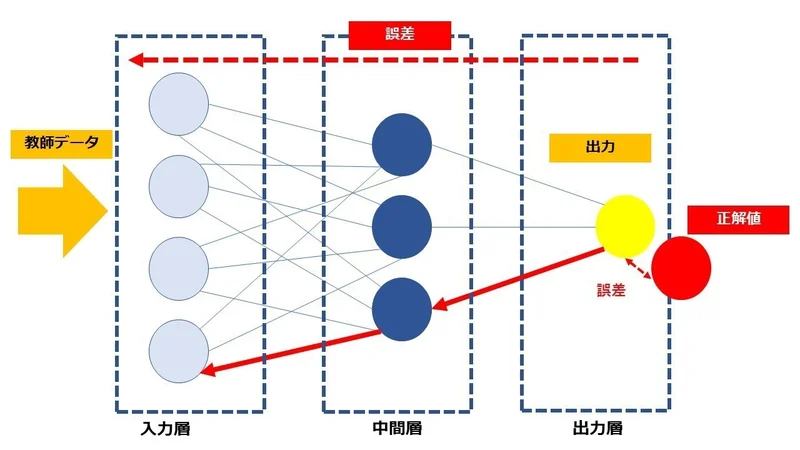

[【3分で理解】ニューラルネットワークを解説！後編「多層パーセプトロン」とは？｜村田泰祐](https://note.com/taisuke_murata/n/nb470ea2eaa8e)

## 4次元3層DNNを試みる

In [60]:
# Scikit Learnのニューラルネットワークのライブラリを読み込む
# from sklearn.neural_network import MLPClassifier
# ニューラルネットワークのモデルを作成
clf4deep = MLPClassifier(hidden_layer_sizes=(10,10,10), activation='relu',
                    solver='adam', max_iter=500)
#hidden_layer_sizes 中間層(隠れ層)のサイズ (10,)2層目の隠れ層は10個の、3層型NN
#activation 活性化関数
#solver 最適化手法
#max_iter 繰り返し回数


### 学習 トレーニングデータによる予測モデル学習

In [62]:
# Lerning model
clf4deep.fit(data_train_std, target_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=500)

### 評価 トレーニングデータによる精度評価

In [64]:
# Calculate prediction accuracy
print("トレーニング正答率: %.2f" %clf4deep.score(data_train_std, target_train))

トレーニング正答率: 0.98


### 評価 テストデータによる精度評価

In [65]:
# Predict test data
print("予測: %s" %clf4deep.predict(data_test_std))
print("教師: %s" %target_test)

target_pred = clf4deep.predict(data_test_std)
print('誤分類: %d' % (target_test != target_pred).sum())
print('テスト正答率: %.2f' % accuracy_score(target_test, target_pred))

予測: [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2 1 1 2 0 2 0 0]
教師: [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1 1 1 2 0 2 0 0]
誤分類: 1
テスト正答率: 0.98


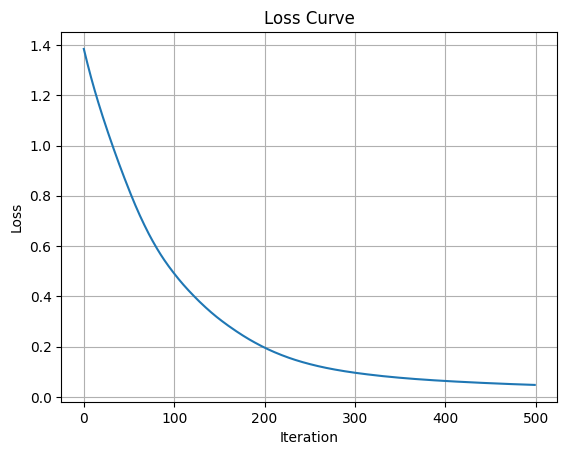

In [67]:
# Show loss function (数列表示)
#print(clf4deep.loss_curve_)

# Show loss curve
plt.plot(clf4deep.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()

# DNNによる特徴空間の可視化

## 2次元3層DNNを構築する

In [68]:
# Scikit Learnのニューラルネットワークのライブラリを読み込む
# from sklearn.neural_network import MLPClassifier
# ニューラルネットワークのモデルを作成
clf2deep = MLPClassifier(hidden_layer_sizes=(10,10,10), activation='relu',
                    solver='adam', max_iter=5000)
#hidden_layer_sizes 中間層(隠れ層)のサイズ (10,)2層目の隠れ層は10個の、3層型NN
#activation 活性化関数
#solver 最適化手法
#max_iter 繰り返し回数


## 学習 トレーニングデータによる予測モデル学習

単層パーセプトロンで分割したデータセット(X_train_std, ytrain)を用いる。


In [69]:
# Lerning model
clf2deep.fit(X_train_std, y_train)

MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=5000)

## 評価 トレーニングデータによる精度評価

In [70]:
# Calculate prediction accuracy
print("トレーニング正答率: %.2f" %clf2deep.score(X_train_std, y_train))

トレーニング正答率: 0.96


## 評価 テストデータによる精度評価

In [71]:
# Predict test data
print("予測: %s" %clf2deep.predict(X_test_std))
print("教師: %s" %y_test)

target_pred = clf2deep.predict(X_test_std)
print('誤分類: %d' % (y_test != target_pred).sum())
print('テスト正答率: %.2f' % accuracy_score(y_test, y_pred))

予測: [2 2 2 0 2 0 0 2 1 0 1 0 1 2 0 0 1 2 1 0 0 2 0 1 2 0 1 2 1 1 2 1 1 1 2 0 2
 2 1 1 2 0 1 0 0]
教師: [2 2 2 0 2 0 0 1 1 0 1 0 1 2 0 0 1 2 1 0 0 2 0 1 2 0 1 2 1 1 2 2 1 1 2 0 2
 2 1 1 2 0 1 0 0]
誤分類: 2
テスト正答率: 0.91


## 学習過程の表示

損失関数の減少過程を確認する。

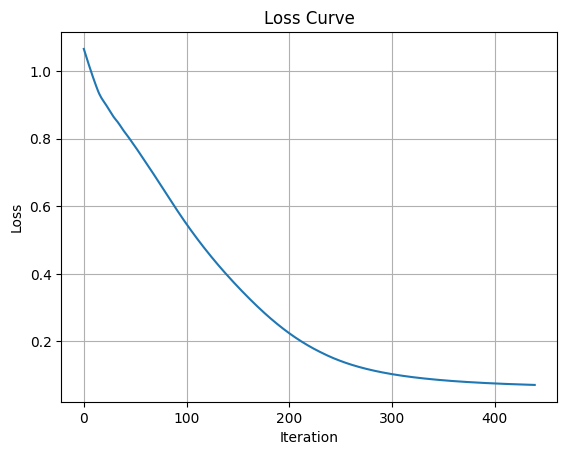

In [72]:
# Show loss curve
plt.plot(clf2deep.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()

## 特徴空間の可視化


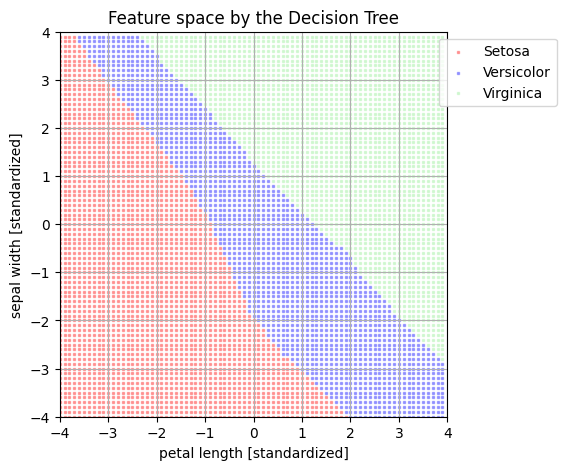

In [73]:
# PyLearnMLCR01: 決定木 | 知能情報システム工学研究室 – 日本大学生産工学部マネジメント工学科
# http://int-info.com/PyLearn/PyLearnMLCR01.html

Xmin, Ymin, Xmax, Ymax = -4, -4, 4, 4 # 空間の最小最大値
resolution = 0.1 # 細かさ
x_mesh, y_mesh = np.meshgrid(np.arange(Xmin, Xmax, resolution),
                             np.arange(Ymin, Ymax, resolution))
MeshDat = np.array([x_mesh.ravel(), y_mesh.ravel()]).T
#print(np.shape(MeshDat))
#print(MeshDat)

z = clf2deep.predict(MeshDat)
z = np.reshape(z,(len(x_mesh),len(y_mesh)))
#print(z)

# 推論(Setosa, Versicolor, Virginica領域)
plt.figure(figsize=(5,5))
plt.scatter(x_mesh[z==0], y_mesh[z==0], s=4.5, alpha=0.3, marker="s", c='red')
plt.scatter(x_mesh[z==1], y_mesh[z==1], s=4.5, alpha=0.3, marker="s", c='blue')
plt.scatter(x_mesh[z==2], y_mesh[z==2], s=4.5, alpha=0.3, marker="s", c='lightgreen')


plt.title("Feature space by the Decision Tree")
plt.xlabel('petal length [standardized]')
plt.ylabel('sepal width [standardized]')
plt.grid(True)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.legend(["Setosa", "Versicolor", "Virginica"], loc="upper right", bbox_to_anchor=(1.3, 1))


/tmp/ipykernel_843/4035606091.py:15: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x1tr, y1tr, alpha=0.8, marker="x", c='blue',edgecolor='black',label="Versicolor")
/tmp/ipykernel_843/4035606091.py:27: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x1ts, y1ts, alpha=0.8, marker="x", c='blue',edgecolor='black')


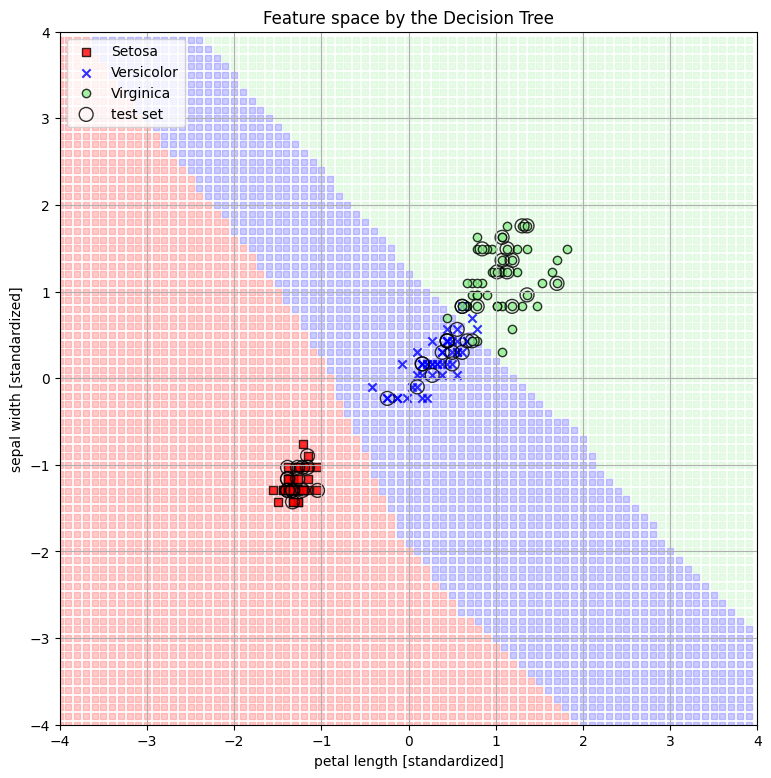

In [74]:
# 推論(Setosa, Versicolor, Virginica領域)
plt.figure(figsize=(9,9))
plt.scatter(x_mesh[z==0], y_mesh[z==0], s=20, alpha=0.2, marker="s", c='red')
plt.scatter(x_mesh[z==1], y_mesh[z==1], s=20, alpha=0.2, marker="s", c='blue')
plt.scatter(x_mesh[z==2], y_mesh[z==2], s=20, alpha=0.2, marker="s", c='lightgreen')

#トレーニングデータ(Setosa, Versicolor, Virginica)
x0tr = X_train_std[y_train==0][:, 0] #ブール配列によるマスキング
y0tr = X_train_std[y_train==0][:, 1]
x1tr = X_train_std[y_train==1][:, 0]
y1tr = X_train_std[y_train==1][:, 1]
x2tr = X_train_std[y_train==2][:, 0]
y2tr = X_train_std[y_train==2][:, 1]
plt.scatter(x0tr, y0tr, alpha=0.8, marker="s", c='red', edgecolor='black',label="Setosa")
plt.scatter(x1tr, y1tr, alpha=0.8, marker="x", c='blue',edgecolor='black',label="Versicolor")
plt.scatter(x2tr, y2tr, alpha=0.8, marker="o", c='lightgreen',edgecolor='black',label="Virginica")

#テストデータ(Setosa, Versicolor, Virginica)
x0ts = X_test_std[y_test==0][:, 0]
y0ts = X_test_std[y_test==0][:, 1]
x1ts = X_test_std[y_test==1][:, 0]
y1ts = X_test_std[y_test==1][:, 1]
x2ts = X_test_std[y_test==2][:, 0]
y2ts = X_test_std[y_test==2][:, 1]
plt.scatter(x0ts, y0ts, alpha=0.8, marker="s", c='red', edgecolor='black')
plt.scatter(x0ts, y0ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black',label='test set')
plt.scatter(x1ts, y1ts, alpha=0.8, marker="x", c='blue',edgecolor='black')
plt.scatter(x1ts, y1ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black')
plt.scatter(x2ts, y2ts, alpha=0.8, marker="o", c='lightgreen',edgecolor='black')
plt.scatter(x2ts, y2ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black')


plt.title("Feature space by the Decision Tree")
plt.xlabel('petal length [standardized]')
plt.ylabel('sepal width [standardized]')
plt.grid(True)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.legend(loc='upper left')
#plt.legend(["Setosa", "Versicolor", "Virginica"], loc="upper right", bbox_to_anchor=(1.3, 1))